# Rules based Grouping

From user_features.csv, we will create groups based on our observations from the EDA and our domain knowledge.

In [29]:
import pandas as pd

In [30]:
user_features = pd.read_csv('data/user_features.csv')

In [31]:
user_features

,user_id,Age,gender,home_country,home_city,married,has_children,Age Group,trip_session_ratio,nights_median,hotel_tot_rev,hotel_avg_rev,hotels_no_bookings,hotel_tot_nights,hotel_avg_nights,flight_no_bookings,flight_avg_seats,flight_avg_rev,flight_tot_rev
0,94883,54,F,usa,kansas city,True,False,Age Group 50-65,3.666667,1.0,230.00,115.000000,2.0,2.0,1.000000,3.0,1.666667,3489.600000,10468.8000
1,101486,53,F,usa,tacoma,True,True,Age Group 50-65,3.333333,4.0,2640.00,880.000000,3.0,11.0,3.666667,2.0,1.000000,175.871250,351.7425
2,101961,45,F,usa,boston,True,False,Age Group 35-50,1.714286,4.0,3520.00,502.857143,7.0,26.0,3.714286,6.0,1.000000,320.705500,1924.2330
3,106907,47,F,usa,miami,True,True,Age Group 35-50,1.500000,6.0,2185.20,1092.600000,2.0,12.0,6.000000,1.0,1.000000,165.510000,165.5100
4,118043,54,F,usa,los angeles,False,True,Age Group 50-65,2.200000,6.5,6443.45,1610.862500,4.0,24.0,6.000000,3.0,2.000000,1708.853333,5126.5600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,52,F,usa,los angeles,True,True,Age Group 50-65,2.500000,1.0,220.00,220.000000,1.0,1.0,1.000000,2.0,1.500000,798.591000,1597.1820
5778,785186,47,F,usa,little rock,True,True,Age Group 35-50,4.000000,1.5,475.00,237.500000,2.0,3.0,1.500000,2.0,1.000000,176.675000,353.3500
5779,792549,48,F,usa,kansas city,False,False,Age Group 35-50,2.000000,5.0,180.00,180.000000,1.0,5.0,5.000000,4.0,1.000000,259.792500,1039.1700
5780,811077,47,F,usa,knoxville,True,True,Age Group 35-50,8.000000,7.0,994.00,994.000000,1.0,7.0,7.000000,1.0,1.000000,579.790000,579.7900


# Revenue Groups

## Hotel Revenue
just and idea (not completed)

In [33]:
user_features.columns

Index(['user_id', 'Age', 'gender', 'home_country', 'home_city', 'married',
       'has_children', 'Age Group', 'trip_session_ratio', 'nights_median',
       'hotel_tot_rev', 'hotel_avg_rev', 'hotels_no_bookings',
       'hotel_tot_nights', 'hotel_avg_nights', 'flight_no_bookings',
       'flight_avg_seats', 'flight_avg_rev', 'flight_tot_rev'],
      dtype='str')

In [34]:
user_features[['user_id','hotel_tot_rev', 'hotel_avg_rev', 'hotels_no_bookings',
       'hotel_tot_nights', 'hotel_avg_nights']]

,user_id,hotel_tot_rev,hotel_avg_rev,hotels_no_bookings,hotel_tot_nights,hotel_avg_nights
0,94883,230.00,115.000000,2.0,2.0,1.000000
1,101486,2640.00,880.000000,3.0,11.0,3.666667
2,101961,3520.00,502.857143,7.0,26.0,3.714286
3,106907,2185.20,1092.600000,2.0,12.0,6.000000
4,118043,6443.45,1610.862500,4.0,24.0,6.000000
...,...,...,...,...,...,...
5777,780167,220.00,220.000000,1.0,1.0,1.000000
5778,785186,475.00,237.500000,2.0,3.0,1.500000
5779,792549,180.00,180.000000,1.0,5.0,5.000000
5780,811077,994.00,994.000000,1.0,7.0,7.000000


In [35]:
user_features["hotel_avg_rev_per_night"] = user_features["hotel_avg_rev"]/user_features["hotel_avg_nights"]

In [38]:
user_features["hotel_avg_rev_per_night_delta"] = user_features["hotel_avg_rev_per_night"] - user_features["hotel_avg_rev_per_night"].mean()

In [39]:
user_features

,user_id,Age,gender,home_country,home_city,married,has_children,Age Group,trip_session_ratio,nights_median,...,hotel_avg_rev,hotels_no_bookings,hotel_tot_nights,hotel_avg_nights,flight_no_bookings,flight_avg_seats,flight_avg_rev,flight_tot_rev,hotel_avg_rev_per_night,hotel_avg_rev_per_night_delta
0,94883,54,F,usa,kansas city,True,False,Age Group 50-65,3.666667,1.0,...,115.000000,2.0,2.0,1.000000,3.0,1.666667,3489.600000,10468.8000,115.000000,-96.800789
1,101486,53,F,usa,tacoma,True,True,Age Group 50-65,3.333333,4.0,...,880.000000,3.0,11.0,3.666667,2.0,1.000000,175.871250,351.7425,240.000000,28.199211
2,101961,45,F,usa,boston,True,False,Age Group 35-50,1.714286,4.0,...,502.857143,7.0,26.0,3.714286,6.0,1.000000,320.705500,1924.2330,135.384615,-76.416173
3,106907,47,F,usa,miami,True,True,Age Group 35-50,1.500000,6.0,...,1092.600000,2.0,12.0,6.000000,1.0,1.000000,165.510000,165.5100,182.100000,-29.700789
4,118043,54,F,usa,los angeles,False,True,Age Group 50-65,2.200000,6.5,...,1610.862500,4.0,24.0,6.000000,3.0,2.000000,1708.853333,5126.5600,268.477083,56.676295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,52,F,usa,los angeles,True,True,Age Group 50-65,2.500000,1.0,...,220.000000,1.0,1.0,1.000000,2.0,1.500000,798.591000,1597.1820,220.000000,8.199211
5778,785186,47,F,usa,little rock,True,True,Age Group 35-50,4.000000,1.5,...,237.500000,2.0,3.0,1.500000,2.0,1.000000,176.675000,353.3500,158.333333,-53.467455
5779,792549,48,F,usa,kansas city,False,False,Age Group 35-50,2.000000,5.0,...,180.000000,1.0,5.0,5.000000,4.0,1.000000,259.792500,1039.1700,36.000000,-175.800789
5780,811077,47,F,usa,knoxville,True,True,Age Group 35-50,8.000000,7.0,...,994.000000,1.0,7.0,7.000000,1.0,1.000000,579.790000,579.7900,142.000000,-69.800789


# High Spenders

In [52]:
user_features["total_avg_revenue"] =  user_features["hotel_avg_rev"] + user_features["flight_avg_rev"]

In [53]:
user_features

,user_id,Age,gender,home_country,home_city,married,has_children,Age Group,trip_session_ratio,nights_median,...,hotel_tot_nights,hotel_avg_nights,flight_no_bookings,flight_avg_seats,flight_avg_rev,flight_tot_rev,hotel_avg_rev_per_night,hotel_avg_rev_per_night_delta,total_revenue,total_avg_revenue
0,94883,54,F,usa,kansas city,True,False,Age Group 50-65,3.666667,1.0,...,2.0,1.000000,3.0,1.666667,3489.600000,10468.8000,115.000000,-96.800789,10698.8000,3604.600000
1,101486,53,F,usa,tacoma,True,True,Age Group 50-65,3.333333,4.0,...,11.0,3.666667,2.0,1.000000,175.871250,351.7425,240.000000,28.199211,2991.7425,1055.871250
2,101961,45,F,usa,boston,True,False,Age Group 35-50,1.714286,4.0,...,26.0,3.714286,6.0,1.000000,320.705500,1924.2330,135.384615,-76.416173,5444.2330,823.562643
3,106907,47,F,usa,miami,True,True,Age Group 35-50,1.500000,6.0,...,12.0,6.000000,1.0,1.000000,165.510000,165.5100,182.100000,-29.700789,2350.7100,1258.110000
4,118043,54,F,usa,los angeles,False,True,Age Group 50-65,2.200000,6.5,...,24.0,6.000000,3.0,2.000000,1708.853333,5126.5600,268.477083,56.676295,11570.0100,3319.715833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,52,F,usa,los angeles,True,True,Age Group 50-65,2.500000,1.0,...,1.0,1.000000,2.0,1.500000,798.591000,1597.1820,220.000000,8.199211,1817.1820,1018.591000
5778,785186,47,F,usa,little rock,True,True,Age Group 35-50,4.000000,1.5,...,3.0,1.500000,2.0,1.000000,176.675000,353.3500,158.333333,-53.467455,828.3500,414.175000
5779,792549,48,F,usa,kansas city,False,False,Age Group 35-50,2.000000,5.0,...,5.0,5.000000,4.0,1.000000,259.792500,1039.1700,36.000000,-175.800789,1219.1700,439.792500
5780,811077,47,F,usa,knoxville,True,True,Age Group 35-50,8.000000,7.0,...,7.0,7.000000,1.0,1.000000,579.790000,579.7900,142.000000,-69.800789,1573.7900,1573.790000


In [54]:
import seaborn as sns

<Axes: ylabel='total_avg_revenue'>

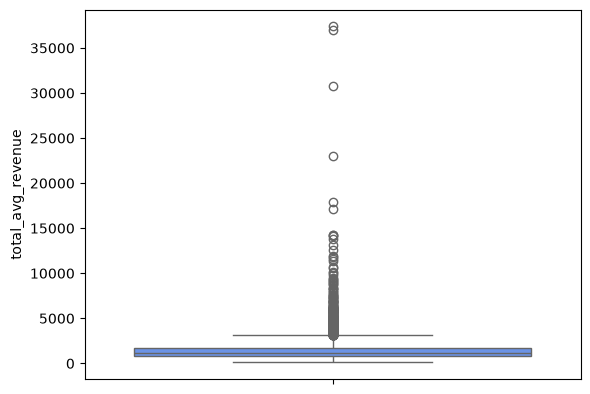

In [55]:
sns.boxplot(user_features, y="total_avg_revenue")

<Axes: ylabel='total_avg_revenue'>

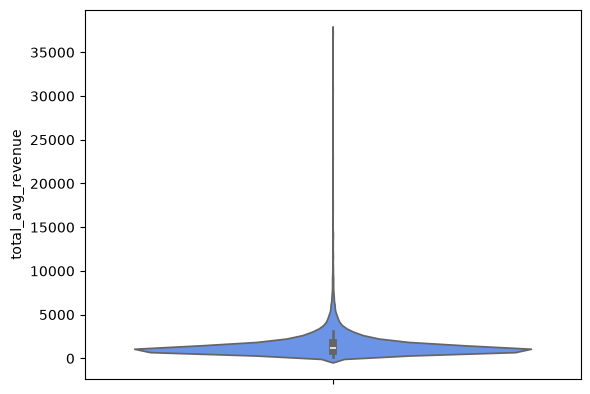

In [56]:
sns.violinplot(user_features, y="total_avg_revenue")

In [57]:
user_features["total_avg_revenue"].describe()

count     4797.000000
mean      1517.778091
std       1555.279298
min        117.446000
25%        813.036833
50%       1145.333333
75%       1728.227500
max      37398.815833
Name: total_avg_revenue, dtype: float64

In [58]:
outlier_limit = (user_features["total_avg_revenue"].quantile(0.75) - user_features["total_avg_revenue"].quantile(0.25))*1.5 + user_features["total_avg_revenue"].quantile(0.75)

In [60]:
user_features["group_high_spenders"] = user_features["total_avg_revenue"] > outlier_limit

In [61]:
user_features

,user_id,Age,gender,home_country,home_city,married,has_children,Age Group,trip_session_ratio,nights_median,...,hotel_avg_nights,flight_no_bookings,flight_avg_seats,flight_avg_rev,flight_tot_rev,hotel_avg_rev_per_night,hotel_avg_rev_per_night_delta,total_revenue,total_avg_revenue,group_high_spenders
0,94883,54,F,usa,kansas city,True,False,Age Group 50-65,3.666667,1.0,...,1.000000,3.0,1.666667,3489.600000,10468.8000,115.000000,-96.800789,10698.8000,3604.600000,True
1,101486,53,F,usa,tacoma,True,True,Age Group 50-65,3.333333,4.0,...,3.666667,2.0,1.000000,175.871250,351.7425,240.000000,28.199211,2991.7425,1055.871250,False
2,101961,45,F,usa,boston,True,False,Age Group 35-50,1.714286,4.0,...,3.714286,6.0,1.000000,320.705500,1924.2330,135.384615,-76.416173,5444.2330,823.562643,False
3,106907,47,F,usa,miami,True,True,Age Group 35-50,1.500000,6.0,...,6.000000,1.0,1.000000,165.510000,165.5100,182.100000,-29.700789,2350.7100,1258.110000,False
4,118043,54,F,usa,los angeles,False,True,Age Group 50-65,2.200000,6.5,...,6.000000,3.0,2.000000,1708.853333,5126.5600,268.477083,56.676295,11570.0100,3319.715833,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,52,F,usa,los angeles,True,True,Age Group 50-65,2.500000,1.0,...,1.000000,2.0,1.500000,798.591000,1597.1820,220.000000,8.199211,1817.1820,1018.591000,False
5778,785186,47,F,usa,little rock,True,True,Age Group 35-50,4.000000,1.5,...,1.500000,2.0,1.000000,176.675000,353.3500,158.333333,-53.467455,828.3500,414.175000,False
5779,792549,48,F,usa,kansas city,False,False,Age Group 35-50,2.000000,5.0,...,5.000000,4.0,1.000000,259.792500,1039.1700,36.000000,-175.800789,1219.1700,439.792500,False
5780,811077,47,F,usa,knoxville,True,True,Age Group 35-50,8.000000,7.0,...,7.000000,1.0,1.000000,579.790000,579.7900,142.000000,-69.800789,1573.7900,1573.790000,False
